In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Iris.csv')

In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df = df.iloc[:,1:]

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()

In [12]:
df['Species'] = encoder.fit_transform(df['Species'])

In [13]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Converting to binary classification 

In [14]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [15]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

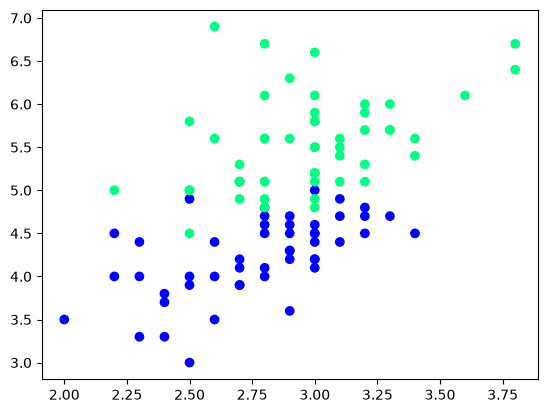

In [17]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [18]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
106,2.5,4.5,2
70,3.2,4.8,1
75,3.0,4.4,1
66,3.0,4.5,1
102,3.0,5.9,2
62,2.2,4.0,1
93,2.3,3.3,1
78,2.9,4.5,1
90,2.6,4.4,1


In [19]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [20]:
df_train

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
98,2.5,3.0,1
141,3.1,5.1,2
102,3.0,5.9,2
118,2.6,6.9,2
131,3.8,6.4,2
88,3.0,4.1,1
70,3.2,4.8,1
50,3.2,4.7,1
51,3.2,4.5,1


In [21]:
df_val

,SepalWidthCm,PetalLengthCm,Species
53,2.3,4.0,1
129,3.0,5.8,2
134,2.6,5.6,2
132,2.8,5.6,2
66,3.0,4.5,1


In [22]:
df_test

,SepalWidthCm,PetalLengthCm,Species
64,2.9,3.6,1
121,2.8,4.9,2
56,3.3,4.7,1
104,3.0,5.8,2
62,2.2,4.0,1


In [23]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [24]:
# y_test
X_test

array([[2.3, 4. ],
       [3. , 5.8],
       [2.6, 5.6],
       [2.8, 5.6],
       [3. , 4.5]])

# Case 1 - Bagging

In [25]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
102,3.0,5.9,2
70,3.2,4.8,1
141,3.1,5.1,2
67,2.7,4.1,1
88,3.0,4.1,1
131,3.8,6.4,2
51,3.2,4.5,1


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [27]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [28]:
dt_bag1 = DecisionTreeClassifier()

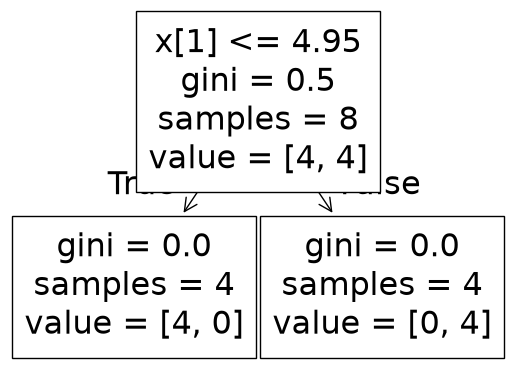

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


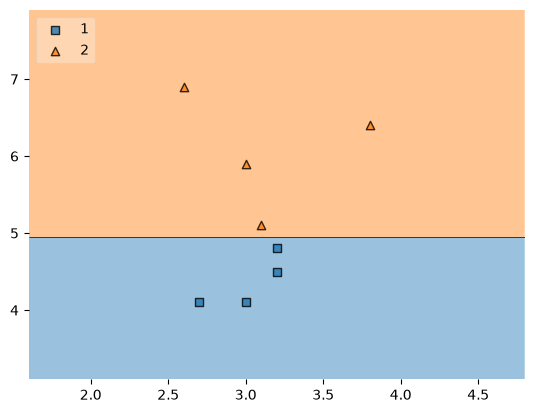

In [29]:
evaluate(dt_bag1,X,y)

In [30]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
118,2.6,6.9,2
50,3.2,4.7,1
67,2.7,4.1,1
70,3.2,4.8,1
102,3.0,5.9,2
98,2.5,3.0,1
70,3.2,4.8,1


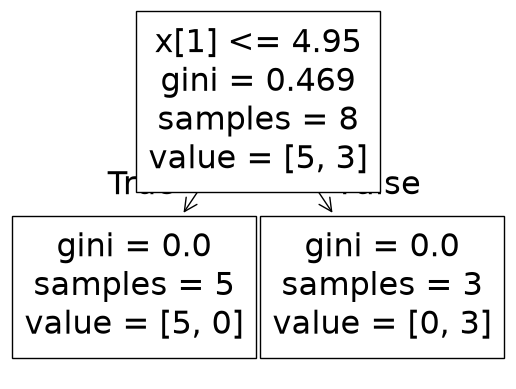

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


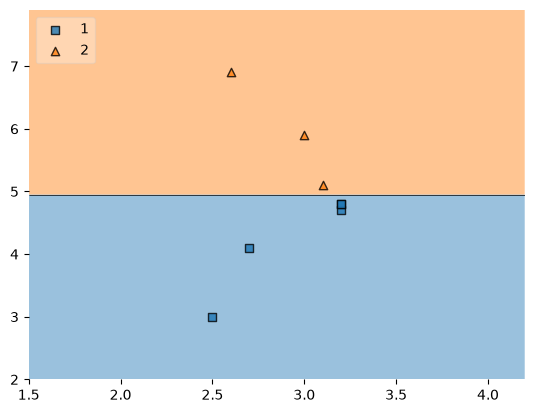

In [31]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [32]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
98,2.5,3.0,1
118,2.6,6.9,2
118,2.6,6.9,2
102,3.0,5.9,2
102,3.0,5.9,2
88,3.0,4.1,1
131,3.8,6.4,2


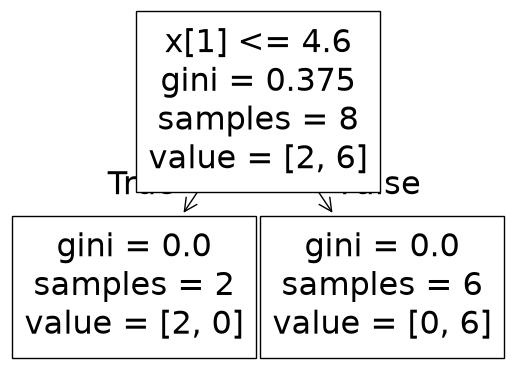

1.0


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


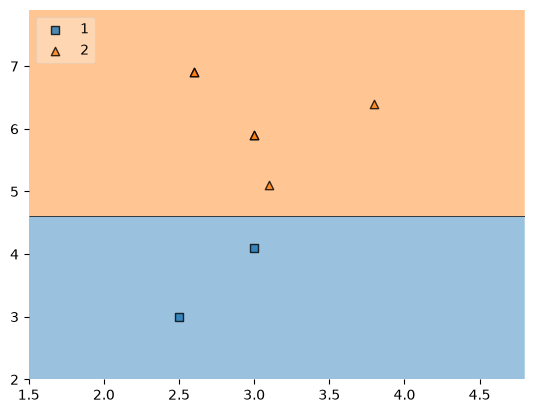

In [33]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [34]:
df_test

,SepalWidthCm,PetalLengthCm,Species
64,2.9,3.6,1
121,2.8,4.9,2
56,3.3,4.7,1
104,3.0,5.8,2
62,2.2,4.0,1


In [35]:
import numpy as np

In [36]:
print("Predictor 1",dt_bag1.predict(np.array([2.9,5.6]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.9,5.6]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.9,5.6]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

Row Sampling without replacement 

In [37]:
# Pasting is Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
98,2.5,3.0,1
141,3.1,5.1,2
102,3.0,5.9,2
118,2.6,6.9,2
131,3.8,6.4,2
88,3.0,4.1,1
70,3.2,4.8,1
50,3.2,4.7,1
51,3.2,4.5,1


In [38]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
51,3.2,4.5,1
98,2.5,3.0,1
141,3.1,5.1,2
67,2.7,4.1,1
70,3.2,4.8,1
102,3.0,5.9,2
118,2.6,6.9,2
50,3.2,4.7,1


# Random Subspaces

We do column sampling  : we can do it with replacement or without replacement 

In [39]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [40]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
129,130,7.2,3.0,5.8,1.6,Iris-virginica
114,115,5.8,2.8,5.1,2.4,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
101,102,5.8,2.7,5.1,1.9,Iris-virginica
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
141,142,6.9,3.1,5.1,2.3,Iris-virginica
47,48,4.6,3.2,1.4,0.2,Iris-setosa
139,140,6.9,3.1,5.4,2.1,Iris-virginica
63,64,6.1,2.9,4.7,1.4,Iris-versicolor
81,82,5.5,2.4,3.7,1.0,Iris-versicolor


In [41]:
df1.sample(2,replace=True,axis=1) # sampling 2 columns with replacement possible ie sometimes columns can repeat

,Species,SepalLengthCm
129,Iris-virginica,7.2
114,Iris-virginica,5.8
103,Iris-virginica,6.3
101,Iris-virginica,5.8
68,Iris-versicolor,6.2
141,Iris-virginica,6.9
47,Iris-setosa,4.6
139,Iris-virginica,6.9
63,Iris-versicolor,6.1
81,Iris-versicolor,5.5


# Random Patches

We do both row and column sampling 

In [42]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
129,130,7.2,3.0,5.8,1.6,Iris-virginica
114,115,5.8,2.8,5.1,2.4,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
101,102,5.8,2.7,5.1,1.9,Iris-virginica
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
141,142,6.9,3.1,5.1,2.3,Iris-virginica
47,48,4.6,3.2,1.4,0.2,Iris-setosa
139,140,6.9,3.1,5.4,2.1,Iris-virginica
63,64,6.1,2.9,4.7,1.4,Iris-versicolor
81,82,5.5,2.4,3.7,1.0,Iris-versicolor


In [43]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)  # chaining the row sampling with the column ie we get 8 rows and oly 2 columns of those rows 

,PetalLengthCm,SepalLengthCm
114,5.1,5.8
81,3.7,5.5
114,5.1,5.8
63,4.7,6.1
101,5.1,5.8
81,3.7,5.5
81,3.7,5.5
114,5.1,5.8


In [44]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)


,Species,PetalLengthCm
141,Iris-virginica,5.1
47,Iris-setosa,1.4
81,Iris-versicolor,3.7
47,Iris-setosa,1.4
81,Iris-versicolor,3.7
47,Iris-setosa,1.4
47,Iris-setosa,1.4
101,Iris-virginica,5.1


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier

In [48]:
# parameters = {
#     'n_estimators': [50, 100],
#     'max_samples': [0.5, 1.0],
#     'bootstrap': [True, False],
#     'max_features': [0.5, 1.0]
# }

# search = GridSearchCV(
#     BaggingClassifier(random_state=42),
#     parameters,
#     cv=5,
#     n_jobs=-1,
#     # verbose=2
# )

# search.fit(X, y)

# print(search.best_params_)
# print(search.best_score_)